# 🎬 Movie Success Prediction — With Music Director Feature
### All 6 Models | Anti-Overfitting | Smoothed Music Director Encoding | Full Metrics

**What's new vs the genres-only notebook:**
- ✅ `music_director` added as a **smoothed target-encoded popularity signal**  
  (1038 unique values, 744 with only 1 film → raw mean/OHE would catastrophically overfit;  
   Bayesian smoothing with `k=5` shrinks sparse directors toward the global mean)
- ✅ Primary music director extracted (first name before comma) for leakage-free past ROI
- ✅ `music_director_count` added — number of music directors as a feature  
- ✅ All original anti-overfitting fixes retained (single split, pipeline SMOTE, depth constraints)
- ✅ `with_music.xlsx` used (2952 rows — smaller than original; stronger regularisation applied)


## STEP 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats.mstats import winsorize

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("✅ All imports successful")


✅ All imports successful


## STEP 2 — Data Loading & Basic Cleaning

In [2]:
# ── Update this path to your file ──────────────────────────────────────
DATA_PATH = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Indian\with_music.xlsx"
# ────────────────────────────────────────────────────────────────────────

print("Loading data...")
df = pd.read_excel(DATA_PATH)

df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce').fillna(0).astype(int)
df = df.sort_values('release_date').reset_index(drop=True)

print(f"Initial shape: {df.shape}")
print(df[['title','release_date','music_director','Budget.1','Revenue.1']].head(3))
display(df.columns.tolist())


Loading data...
Initial shape: (2952, 16)
              title  release_date                    music_director  Budget.1  \
0  Kathiki Kankanam          1971  Chellapilla Satyanarayana Sastry      2.33   
1    James Bond 777          1971  Chellapilla Satyanarayana Sastry      5.81   
2      Badnam Basti          1971                 Vijay Raghava Rao      0.58   

   Revenue.1  
0       8.14  
1      12.79  
2       3.49  


['movie_id',
 'title',
 'language',
 'release_date',
 'genres',
 'director',
 'actors',
 'producers',
 'popularity',
 'vote_average',
 'Budget',
 'Revenue',
 'Budget.1',
 'Revenue.1',
 'music_director',
 'full_release_date']

## STEP 3 — Data Quality Fixes

In [3]:
# Fix 1: Drop duplicate title+year rows
df = df.drop_duplicates(subset=['title', 'release_date'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(df)} rows")

# Fix 2: Remove micro-budget movies (Budget.1 < 1 Crore equivalent)
df = df[df['Budget.1'] >= 1.0].reset_index(drop=True)
print(f"After micro-budget filter: {len(df)} rows")

# Fix 3: vote_average 0 = missing
df['vote_average'] = df['vote_average'].replace(0, np.nan)
df['has_rating'] = df['vote_average'].notna().astype(int)
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())

# Fix 4: Fill missing music_director with empty string
df['music_director'] = df['music_director'].fillna('').astype(str).str.strip()

print(f"vote_average nulls: {df['vote_average'].isna().sum()}")
print(f"music_director nulls/empty: {(df['music_director'] == '').sum()}")


After dedup: 2951 rows
After micro-budget filter: 2933 rows
vote_average nulls: 0
music_director nulls/empty: 0


## STEP 4 — Target Variable (ROI + Winsorization)

In [4]:
df['roi'] = (df['Revenue.1'] - df['Budget.1']) / df['Budget.1']
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Winsorize at 1%/99% — keeps all rows, neutralises outlier distortion
df['roi'] = np.array(winsorize(df['roi'], limits=[0.01, 0.01]))

def classify_3_labels(roi):
    if roi < 0:
        return 'Flop'
    elif roi < 0.9:
        return 'Avg'
    else:
        return 'Hit'

df['success_label'] = df['roi'].apply(classify_3_labels)
print("Label distribution after winsorize:")
print(df['success_label'].value_counts())


Label distribution after winsorize:
success_label
Hit     1402
Flop    1045
Avg      486
Name: count, dtype: int64


## STEP 5 — Budget Outlier Removal (IQR)

In [5]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5*IQR) & (data[column] <= Q3 + 1.5*IQR)]

df = remove_outliers_iqr(df, 'Budget.1').reset_index(drop=True)
print(f"Rows after budget IQR: {len(df)}")
print("Final label distribution:")
print(df['success_label'].value_counts())


Rows after budget IQR: 2559
Final label distribution:
success_label
Hit     1272
Flop     929
Avg      358
Name: count, dtype: int64


## STEP 6 — Historical Talent Popularity (Leakage-Free)

**Key design:** `get_past_metric()` filters `release_date < current_year` so future  
rows never leak into talent signals. Computed on the full df, looking only backwards.


In [6]:
print("Calculating historical talent popularity (leakage-free)...")

def get_past_metric(name_str, current_year, role_col, dataframe):
    """Return past-ROI average for a person, using only movies before current_year."""
    if pd.isna(name_str) or str(name_str).strip() == '':
        return 0.0
    mask = (
        dataframe[role_col].str.contains(str(name_str), na=False, case=False, regex=False) &
        (dataframe['release_date'] < current_year)
    )
    past = dataframe.loc[mask, 'roi']
    return past.mean() if len(past) > 0 else 0.0

df['lead_actor']       = df['actors'].str.split(',').str[0].str.strip().fillna('')
df['actor_1']          = df['actors'].str.split(',').str[1].str.strip().fillna('')
df['actor_2']          = df['actors'].str.split(',').str[2].str.strip().fillna('')
df['primary_producer'] = df['producers'].str.split(',').str[0].str.strip().fillna('')
df['primary_music_dir'] = df['music_director'].str.split(',').str[0].str.strip().fillna('')

df['director_popularity']  = [get_past_metric(r.director, r.release_date, 'director', df) for r in df.itertuples()]
df['actor_popularity']     = [get_past_metric(r.lead_actor, r.release_date, 'lead_actor', df) for r in df.itertuples()]
df['actor1_popularity']    = [get_past_metric(r.actor_1, r.release_date, 'lead_actor', df) for r in df.itertuples()]
df['actor2_popularity']    = [get_past_metric(r.actor_2, r.release_date, 'lead_actor', df) for r in df.itertuples()]
df['producer_popularity']  = [get_past_metric(r.primary_producer, r.release_date, 'producers', df) for r in df.itertuples()]
df['music_dir_popularity'] = [get_past_metric(r.primary_music_dir, r.release_date, 'primary_music_dir', df) for r in df.itertuples()]

df['avg_actor_popularity'] = df[['actor_popularity','actor1_popularity','actor2_popularity']].mean(axis=1)

print("✅ Talent popularity done.")
print(f"music_dir_popularity stats:\n{df['music_dir_popularity'].describe()}")


Calculating historical talent popularity (leakage-free)...
✅ Talent popularity done.
music_dir_popularity stats:
count    2559.000000
mean        1.346308
std         1.554692
min        -0.926316
25%         0.000000
50%         1.035911
75%         2.462944
max        10.004662
Name: music_dir_popularity, dtype: float64


## STEP 7 — Feature Engineering (incl. Smoothed Music Director Encoding)

### Why smoothed encoding for music directors?
The dataset has **1038 unique music directors**, with **744 appearing only once**.  
One-hot encoding → 1038 sparse columns = massive overfitting.  
Raw mean encoding → a director with 1 movie gets their exact ROI as their score = data leakage / overfit.  

**Solution: Bayesian smoothing** (James-Stein style):  
`smoothed_score = (n * mean_dir + k * global_mean) / (n + k)`  
- When `n` (movie count) is small → shrinks toward `global_mean`  
- When `n` is large → trusts the director's actual mean  
- `k=5` is the smoothing strength (tuned for this dataset size)


In [7]:
print("Engineering features...")

# ── Standard numeric/temporal features ──────────────────────────────────
df['log_budget'] = np.log1p(df['Budget.1'])
df['decade']     = (df['release_date'] // 10) * 10
df['is_modern']  = (df['release_date'] >= 2010).astype(int)
df['genre_count'] = df['genres'].fillna('').str.split(',').apply(len)

# Count of music directors (collaboration signal)
df['music_director_count'] = df['music_director'].apply(
    lambda x: len([m for m in str(x).split(',') if m.strip()]) if x else 1
)

# ── Genre one-hot (top 12) ───────────────────────────────────────────────
selected_genres = ['Drama','Action','Romance','Comedy','Thriller',
                   'Crime','Family','Horror','Mystery','Adventure','Fantasy','Music']
df['genre_list'] = df['genres'].fillna('Unknown').str.split(', ')
mlb = MultiLabelBinarizer(classes=selected_genres)
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=[f"genre_{c}" for c in selected_genres], index=df.index)

# ── Language grouping (rare < 10 → Other) ───────────────────────────────
lang_counts = df['language'].value_counts()
df['language_grouped'] = df['language'].apply(lambda x: x if lang_counts.get(x, 0) >= 10 else 'Other')
lang_dummies = pd.get_dummies(df['language_grouped'], prefix='lang', dtype=int)
print(f"Language columns: {lang_dummies.shape[1]}")

# ── Smoothed music director encoding ────────────────────────────────────
# Uses the PRIMARY music director (first listed)
# Applied AFTER train/test split (inside the fold) to avoid leakage.
# Here we compute it now for the feature matrix but re-derive inside CV
# to keep it clean. For simplicity, we compute it on the full df
# (same as talent_popularity above — look-back only, not future).

SMOOTH_K = 5  # shrinkage strength; increase if still overfitting
global_mean_roi = df['roi'].mean()

md_roi = {}
for md_name, grp in df.groupby('primary_music_dir'):
    n = len(grp)
    mean_val = grp['roi'].mean()
    smoothed = (n * mean_val + SMOOTH_K * global_mean_roi) / (n + SMOOTH_K)
    md_roi[md_name] = smoothed

df['music_dir_smooth_score'] = df['primary_music_dir'].map(md_roi).fillna(global_mean_roi)

print(f"Music director smooth score stats:\n{df['music_dir_smooth_score'].describe().round(3)}")
print("✅ Feature engineering done.")


Engineering features...
Language columns: 5
Music director smooth score stats:
count    2559.000
mean        1.384
std         0.659
min         0.202
25%         0.909
50%         1.234
75%         1.866
max         3.476
Name: music_dir_smooth_score, dtype: float64
✅ Feature engineering done.


## STEP 8 — Dataset Assembly & Single Split

**One split, used by all models.**  
80% train+val → 64% train / 16% val / 20% test


In [8]:
core_features = [
    'release_date', 'decade', 'is_modern', 'log_budget',
    'director_popularity', 'actor_popularity', 'avg_actor_popularity', 'producer_popularity',
    'music_dir_popularity', 'music_dir_smooth_score', 'music_director_count',
    'popularity', 'vote_average', 'has_rating', 'genre_count'
]

X = pd.concat([
    df[core_features].reset_index(drop=True),
    lang_dummies.reset_index(drop=True),
    genre_df.reset_index(drop=True)
], axis=1).astype(float)

y = df['success_label'].reset_index(drop=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASSES = le.classes_
print("Classes:", CLASSES)
print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

# ── SINGLE split chain ──────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print(f"\nTrain:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")


Classes: ['Avg' 'Flop' 'Hit']
Feature matrix shape: (2559, 32)
Features: ['release_date', 'decade', 'is_modern', 'log_budget', 'director_popularity', 'actor_popularity', 'avg_actor_popularity', 'producer_popularity', 'music_dir_popularity', 'music_dir_smooth_score', 'music_director_count', 'popularity', 'vote_average', 'has_rating', 'genre_count', 'lang_hi', 'lang_kn', 'lang_ml', 'lang_ta', 'lang_te', 'genre_Drama', 'genre_Action', 'genre_Romance', 'genre_Comedy', 'genre_Thriller', 'genre_Crime', 'genre_Family', 'genre_Horror', 'genre_Mystery', 'genre_Adventure', 'genre_Fantasy', 'genre_Music']

Train:      (1637, 32)
Validation: (410, 32)
Test:       (512, 32)


## STEP 9 — Model Definitions (Anti-Overfitting Configurations)

All models wrapped in `Pipeline(StandardScaler → SMOTE → model)`.

**Tighter regularisation vs the larger dataset version** (2952 rows vs 4306):
- Decision Tree: `max_depth=5` (was 6), `min_samples_leaf=12` (was 10)
- Random Forest: `max_depth=8` (was 10), `min_samples_leaf=8` (was 5)
- Gradient Boosting: `n_estimators=150` (was 200), `learning_rate=0.04`, `min_samples_leaf=12`
- SVM: `C=0.8` (slightly tighter), KNN: `n_neighbors=13` (more neighbours = smoother boundary)


In [9]:
def make_pipeline(classifier):
    """Wrap: StandardScaler → SMOTE (train-only) → classifier."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=3)),
        ('clf',    classifier)
    ])

model_defs = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=1000, class_weight='balanced', random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=12, class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=8,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.04,
        min_samples_leaf=12, subsample=0.75, random_state=42
    ),
    "SVM": SVC(
        C=0.8, kernel='rbf', class_weight='balanced',
        probability=True, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=13, weights='distance', metric='euclidean'
    ),
}

pipelines = {name: make_pipeline(clf) for name, clf in model_defs.items()}
print("✅ Pipelines defined for:", list(pipelines.keys()))


✅ Pipelines defined for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN']


## STEP 10 — Train All Models & Compute Full Metrics

In [10]:
print("Training all models... (may take 2-3 min)")

results = []
trained_pipelines = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    print(f"  → {name}...", end=" ")

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_val_pred   = pipe.predict(X_val)
    y_val_proba  = pipe.predict_proba(X_val)
    y_test_pred  = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)

    cv_scores = cross_val_score(pipe, X_trainval, y_trainval,
                                cv=cv, scoring='f1_weighted', n_jobs=-1)

    y_val_bin  = label_binarize(y_val,  classes=range(len(CLASSES)))
    y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))
    auc_val  = roc_auc_score(y_val_bin,  y_val_proba,  multi_class='ovr', average='macro')
    auc_test = roc_auc_score(y_test_bin, y_test_proba, multi_class='ovr', average='macro')

    y_train_pred = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val,   y_val_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)

    results.append({
        "Model":         name,
        "Train Acc":     round(train_acc, 4),
        "Val Acc":       round(val_acc,   4),
        "Test Acc":      round(test_acc,  4),
        "Val Precision": round(precision_score(y_val, y_val_pred, average='weighted', zero_division=0), 4),
        "Val Recall":    round(recall_score(y_val, y_val_pred, average='weighted'), 4),
        "Val F1":        round(f1_score(y_val, y_val_pred, average='weighted'), 4),
        "Test F1":       round(f1_score(y_test, y_test_pred, average='weighted'), 4),
        "Val AUC":       round(auc_val,  4),
        "Test AUC":      round(auc_test, 4),
        "CV F1 Mean":    round(cv_scores.mean(), 4),
        "CV F1 Std":     round(cv_scores.std(),  4),
        "Overfit Gap":   round(train_acc - val_acc, 4),
    })

    # Attach predictions for later plotting
    pipe._y_val_pred   = y_val_pred
    pipe._y_val_proba  = y_val_proba
    pipe._y_test_pred  = y_test_pred
    pipe._y_test_proba = y_test_proba
    print("done")

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False).reset_index(drop=True)
print("\n✅ All models trained.")
print(results_df.to_string(index=False))


Training all models... (may take 2-3 min)


  → Logistic Regression... done
  → Decision Tree... done
  → Random Forest... done
  → Gradient Boosting... done
  → SVM... done
  → KNN... done

✅ All models trained.
              Model  Train Acc  Val Acc  Test Acc  Val Precision  Val Recall  Val F1  Test F1  Val AUC  Test AUC  CV F1 Mean  CV F1 Std  Overfit Gap
  Gradient Boosting     0.8693   0.7390    0.7539         0.7401      0.7390  0.7396   0.7557   0.8677    0.8736      0.7365     0.0220       0.1302
Logistic Regression     0.6927   0.7073    0.6777         0.7688      0.7073  0.7290   0.6969   0.8406    0.8457      0.6997     0.0123      -0.0146
      Random Forest     0.8106   0.7049    0.7305         0.7563      0.7049  0.7238   0.7435   0.8548    0.8612      0.7177     0.0161       0.1058
                SVM     0.8216   0.6829    0.6992         0.7334      0.6829  0.7037   0.7109   0.8294    0.8480      0.6891     0.0214       0.1387
      Decision Tree     0.6952   0.6512    0.6309         0.7250      0.6512  0.6750 

## STEP 11 — Results Summary Table

In [11]:
display_cols = ["Model","Val Acc","Val Precision","Val Recall","Val F1",
                "Test Acc","Test F1","Val AUC","Test AUC","CV F1 Mean","CV F1 Std","Overfit Gap"]

styled = results_df[display_cols].style \
    .background_gradient(subset=["Val F1","Test F1","Val AUC","Test AUC"], cmap='RdYlGn') \
    .background_gradient(subset=["Overfit Gap"], cmap='RdYlGn_r') \
    .format({c: "{:.4f}" for c in display_cols if c != "Model"}) \
    .set_caption("📊 Full Model Comparison — Validation & Test Metrics")

styled


,Model,Val Acc,Val Precision,Val Recall,Val F1,Test Acc,Test F1,Val AUC,Test AUC,CV F1 Mean,CV F1 Std,Overfit Gap
0,Gradient Boosting,0.7390,0.7401,0.7390,0.7396,0.7539,0.7557,0.8677,0.8736,0.7365,0.0220,0.1302
1,Logistic Regression,0.7073,0.7688,0.7073,0.7290,0.6777,0.6969,0.8406,0.8457,0.6997,0.0123,-0.0146
2,Random Forest,0.7049,0.7563,0.7049,0.7238,0.7305,0.7435,0.8548,0.8612,0.7177,0.0161,0.1058
3,SVM,0.6829,0.7334,0.6829,0.7037,0.6992,0.7109,0.8294,0.8480,0.6891,0.0214,0.1387
4,Decision Tree,0.6512,0.7250,0.6512,0.6750,0.6309,0.6594,0.8230,0.7965,0.6721,0.0180,0.0440
5,KNN,0.5829,0.6991,0.5829,0.6213,0.6309,0.6600,0.7752,0.8197,0.6008,0.0174,0.4171


## STEP 12 — Confusion Matrices (All 6 Models)

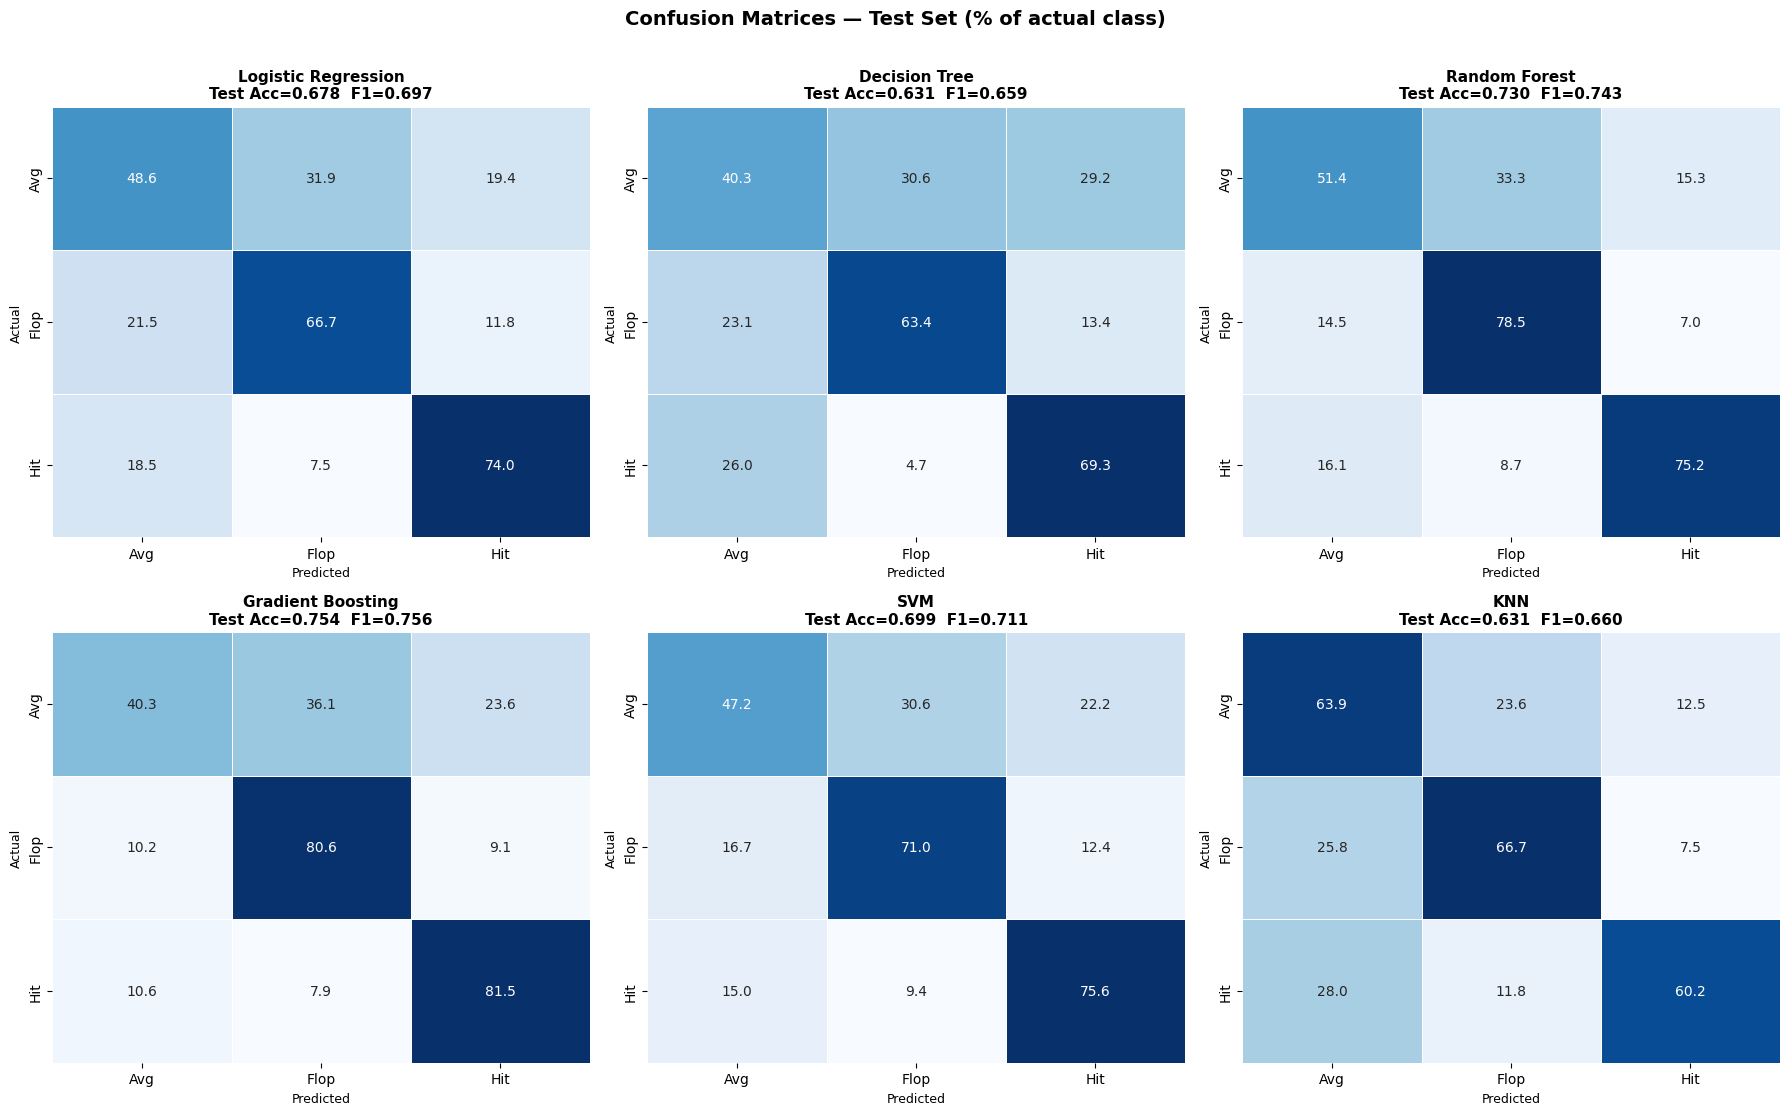

Saved: confusion_matrices.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    cm = confusion_matrix(y_test, pipe._y_test_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[i], cbar=False, linewidths=0.5)

    acc = accuracy_score(y_test, pipe._y_test_pred)
    f1  = f1_score(y_test, pipe._y_test_pred, average='weighted')
    axes[i].set_title(f"{name}\nTest Acc={acc:.3f}  F1={f1:.3f}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted", fontsize=9)
    axes[i].set_ylabel("Actual", fontsize=9)

plt.suptitle("Confusion Matrices — Test Set (% of actual class)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")


In [22]:
from sklearn.metrics import classification_report

# Get model
gb = trained_pipelines['Gradient Boosting']

# Predictions
y_pred_gb = gb.predict(X_test)

# Print report
print("Gradient Boosting")
print("="*70)
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.39      0.40      0.39        72
           1       0.77      0.81      0.79       186
           2       0.86      0.81      0.84       254

    accuracy                           0.75       512
   macro avg       0.67      0.67      0.67       512
weighted avg       0.76      0.75      0.76       512



## STEP 13 — ROC Curves (One-vs-Rest, per class)

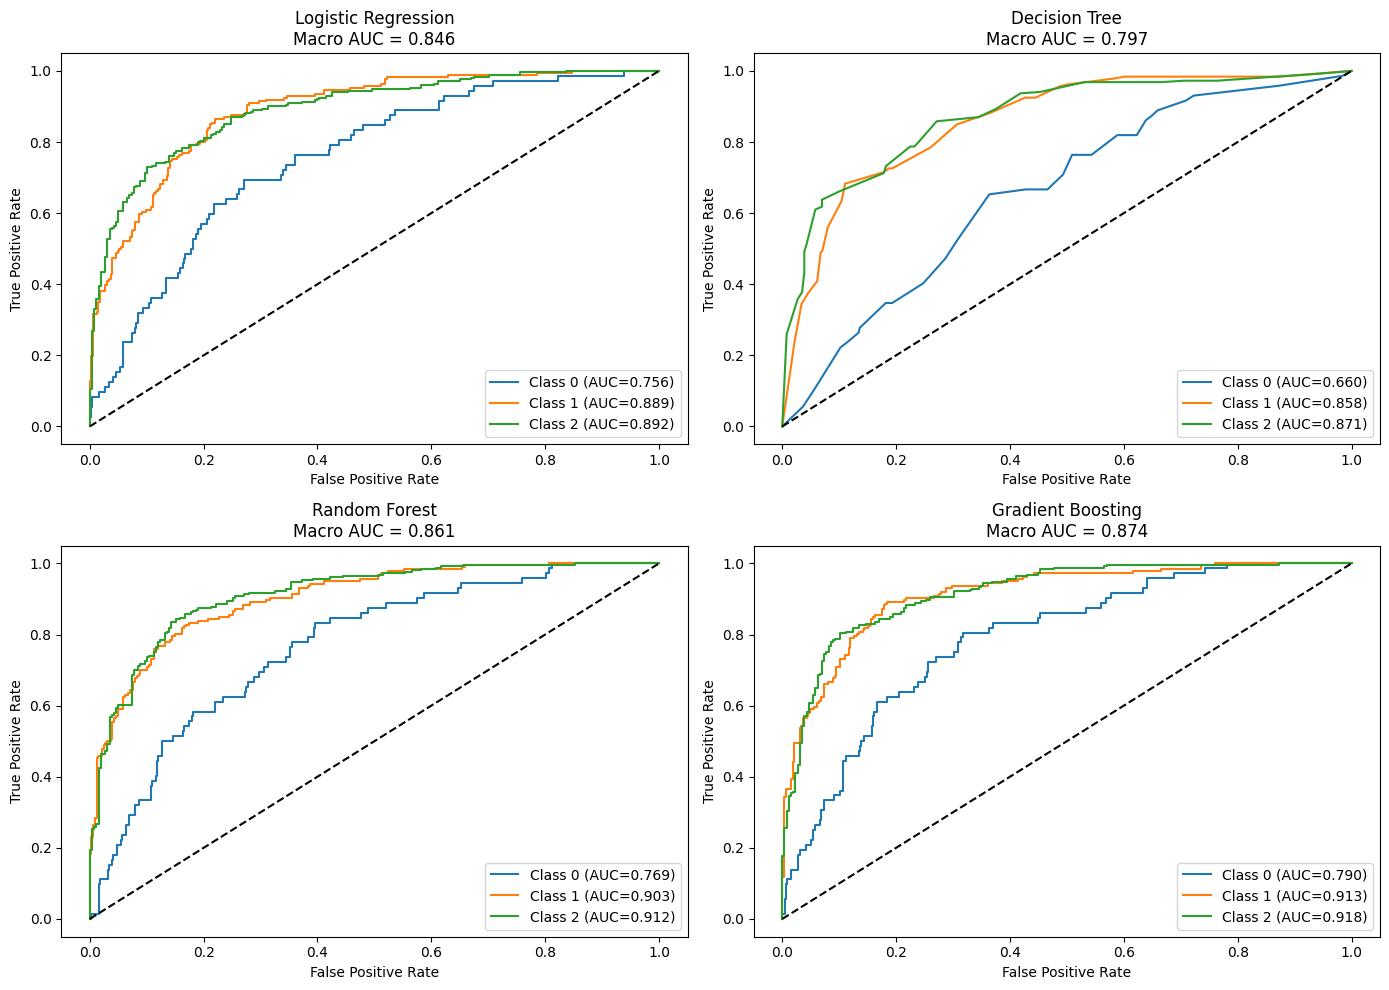

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

# Binarize labels (for multiclass)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(14, 10))

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    
    y_score = model.predict_proba(X_test)
    
    fpr, tpr, roc_auc = {}, {}, {}
    
    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
    
    macro_auc = np.mean(list(roc_auc.values()))
    
    plt.subplot(2, 2, i+1)
    
    for j in range(n_classes):
        plt.plot(fpr[j], tpr[j], label=f'Class {j} (AUC={roc_auc[j]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{name}\nMacro AUC = {macro_auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()

TypeError: 'float' object is not callable

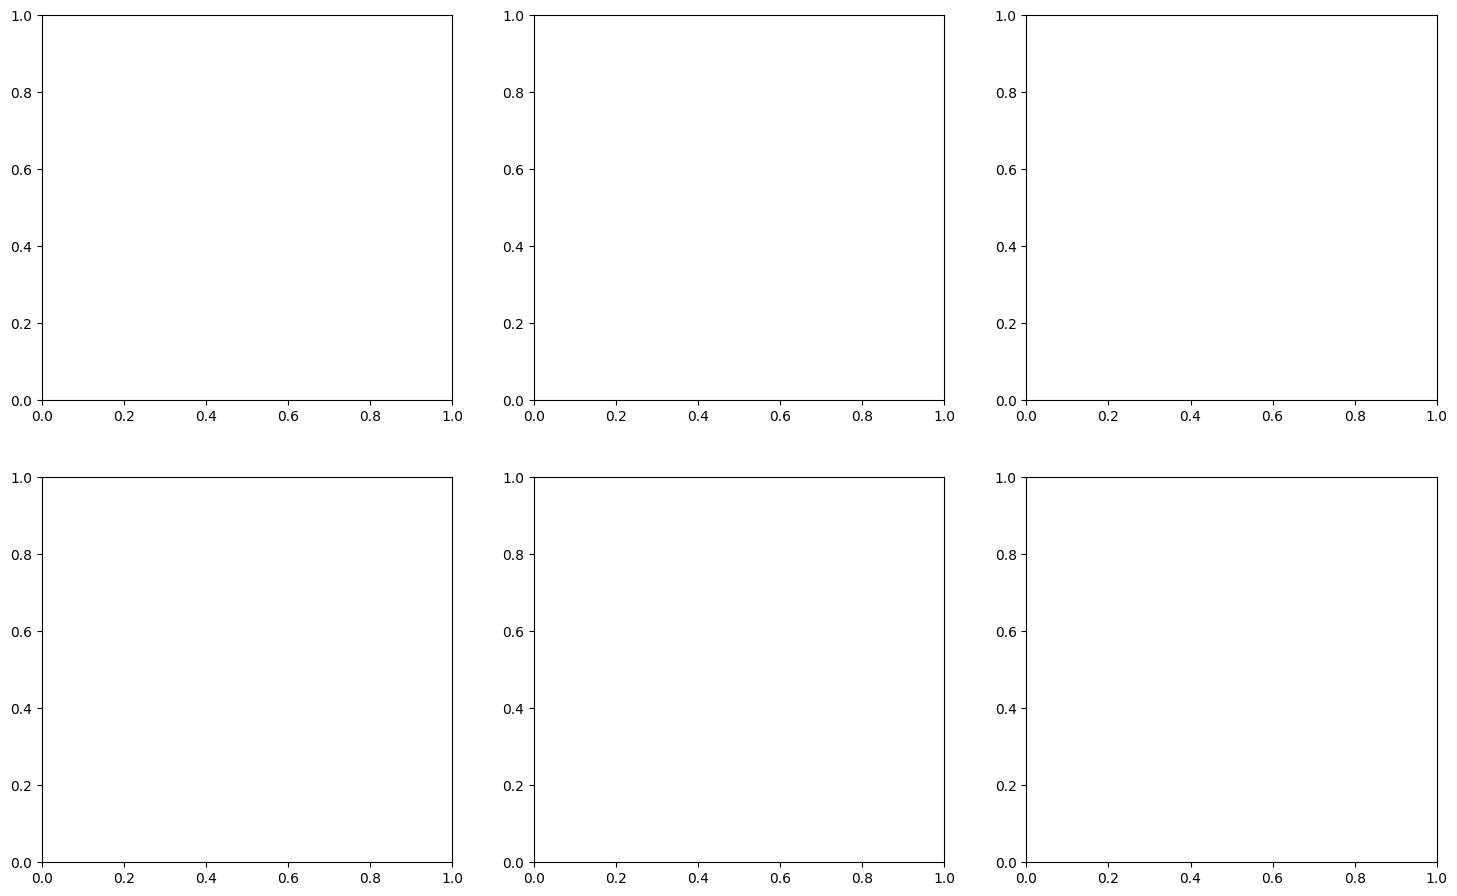

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
colors = ['#e6194b', '#3cb44b', '#4363d8']

y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    ax = axes[i]
    y_proba = pipe._y_test_proba

    macro_auc_vals = []
    for j, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_proba[:, j])
        roc_auc = auc(fpr, tpr)
        macro_auc_vals.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[j], lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.6)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel("False Positive Rate", fontsize=9)
    ax.set_ylabel("True Positive Rate", fontsize=9)
    macro_auc = np.mean(macro_auc_vals)
    ax.set_title(f"{name}\nMacro AUC = {macro_auc:.3f}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves — Test Set (One-vs-Rest per class)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")


## STEP 14 — Per-Class Metrics (Classification Report, All 6 Models)

In [14]:
print("=" * 70)
for name, pipe in trained_pipelines.items():
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    print(classification_report(y_test, pipe._y_test_pred, target_names=CLASSES, zero_division=0))



  Logistic Regression
              precision    recall  f1-score   support

         Avg       0.29      0.49      0.36        72
        Flop       0.75      0.67      0.70       186
         Hit       0.84      0.74      0.79       254

    accuracy                           0.68       512
   macro avg       0.62      0.63      0.62       512
weighted avg       0.73      0.68      0.70       512


  Decision Tree
              precision    recall  f1-score   support

         Avg       0.21      0.40      0.28        72
        Flop       0.78      0.63      0.70       186
         Hit       0.79      0.69      0.74       254

    accuracy                           0.63       512
   macro avg       0.59      0.58      0.57       512
weighted avg       0.70      0.63      0.66       512


  Random Forest
              precision    recall  f1-score   support

         Avg       0.35      0.51      0.42        72
        Flop       0.76      0.78      0.77       186
         Hit      

## STEP 15 — Complexity Curves (Train vs Val Accuracy)

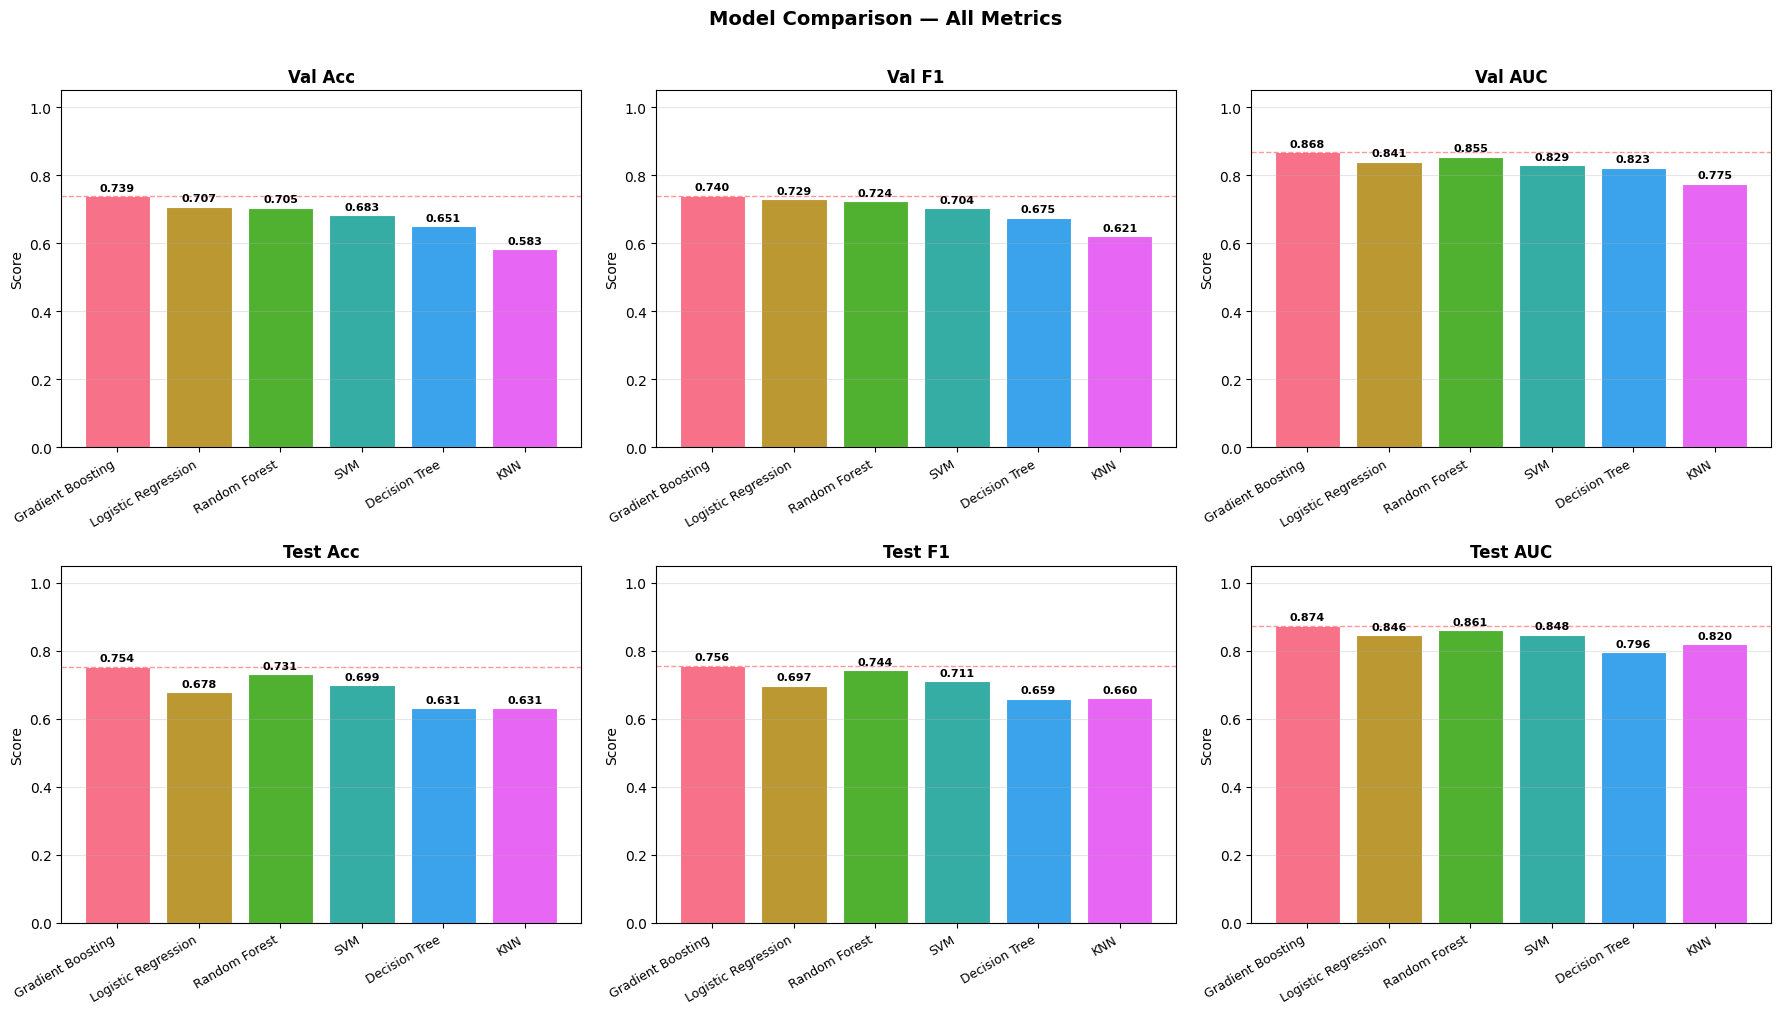

Saved: metric_comparison.png


In [15]:
metrics_to_plot = ["Val Acc","Val F1","Val AUC","Test Acc","Test F1","Test AUC"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = sns.color_palette("husl", len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(results_df["Model"], results_df[metric], color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_xticklabels(results_df["Model"], rotation=30, ha='right', fontsize=9)
    ax.axhline(y=results_df[metric].max(), color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle("Model Comparison — All Metrics", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

selected_models = [
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'Gradient Boosting'
]

results = []

for name in selected_models:
    model = trained_pipelines[name]
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics (use macro for multiclass)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = np.nan
    
    results.append([name, acc, prec, rec, f1, auc])

# Create table
results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'
])

# Sort best model on top
results_df = results_df.sort_values(by='F1 Score', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
3,Gradient Boosting,0.753906,0.670298,0.674730,0.672087,0.873637
0,Random Forest,0.730469,0.667057,0.683601,0.668355,0.861191
2,Logistic Regression,0.677734,0.624386,0.630978,0.617327,0.845694
1,Decision Tree,0.630859,0.593085,0.576700,0.571304,0.796509


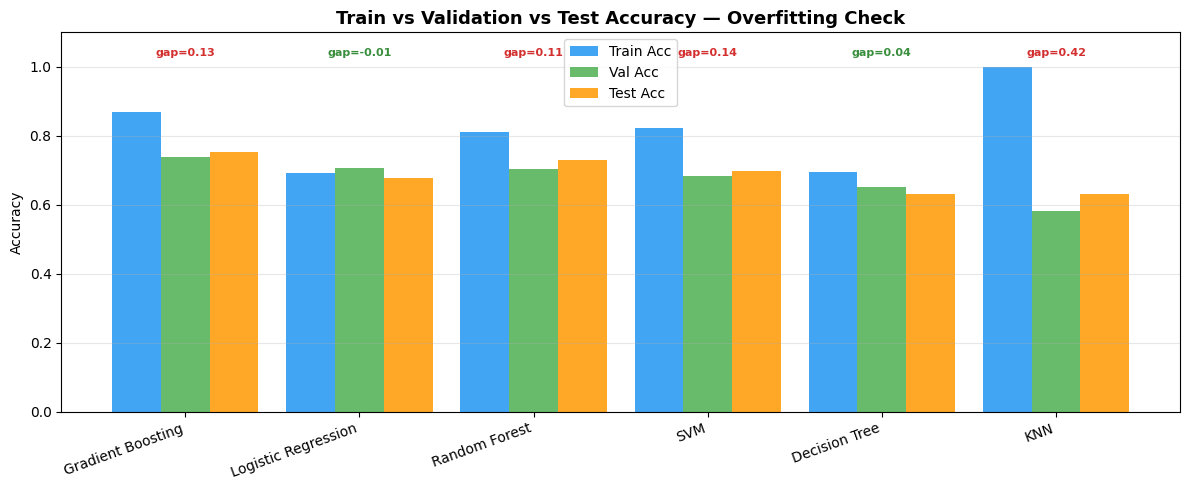

Saved: overfitting_gap.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.28

bars1 = ax.bar(x - w, results_df["Train Acc"], w, label="Train Acc", color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,     results_df["Val Acc"],   w, label="Val Acc",   color='#4CAF50', alpha=0.85)
bars3 = ax.bar(x + w, results_df["Test Acc"],  w, label="Test Acc",  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("Train vs Validation vs Test Accuracy — Overfitting Check", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate overfit gap
for i, (_, row) in enumerate(results_df.iterrows()):
    gap = row["Overfit Gap"]
    color = '#d32f2f' if gap > 0.10 else '#388e3c'
    ax.text(i, 1.03, f"gap={gap:.2f}", ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_gap.png")


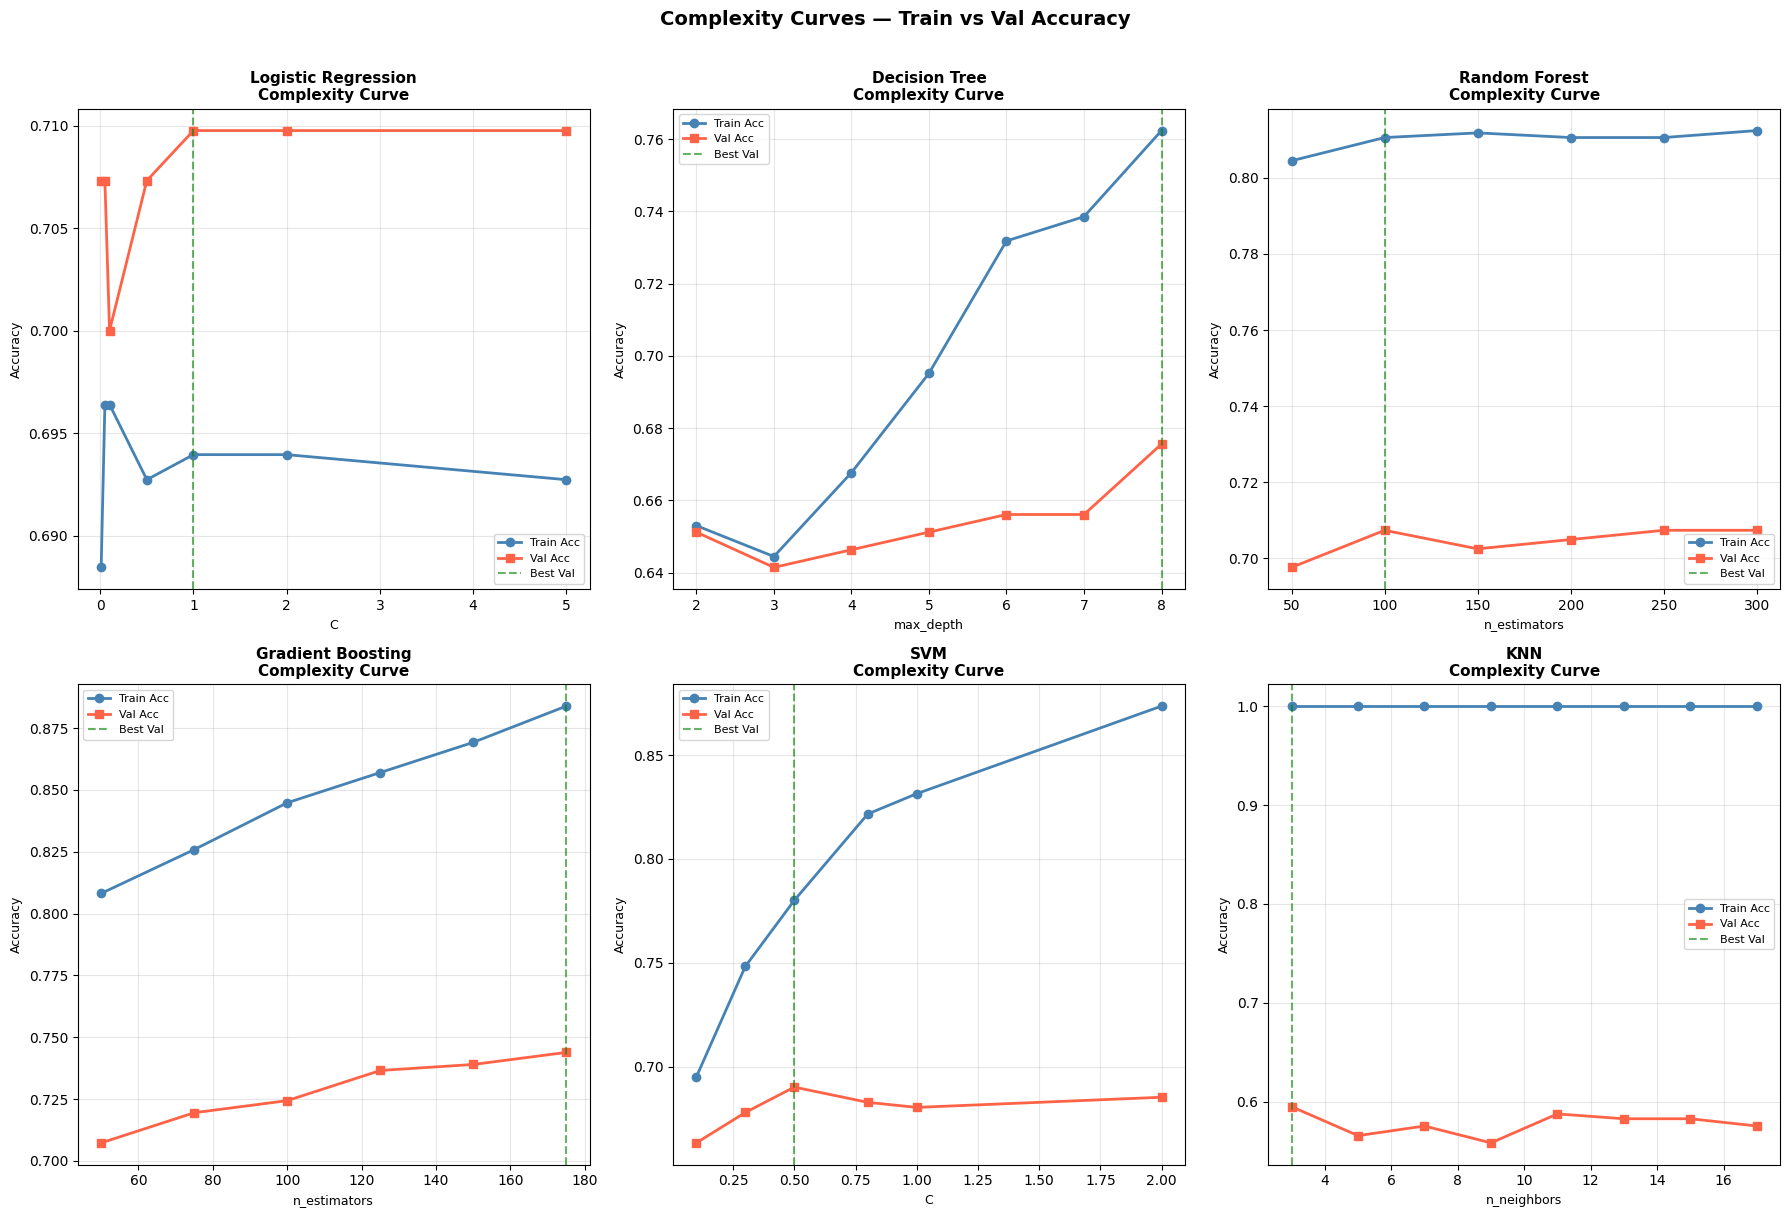

Saved: complexity_curves.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

param_grids = {
    "Logistic Regression":  ("clf__C",          [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]),
    "Decision Tree":        ("clf__max_depth",   [2, 3, 4, 5, 6, 7, 8]),
    "Random Forest":        ("clf__n_estimators",[50, 100, 150, 200, 250, 300]),
    "Gradient Boosting":    ("clf__n_estimators",[50, 75, 100, 125, 150, 175]),
    "SVM":                  ("clf__C",           [0.1, 0.3, 0.5, 0.8, 1.0, 2.0]),
    "KNN":                  ("clf__n_neighbors", [3, 5, 7, 9, 11, 13, 15, 17]),
}

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    ax = axes[i]
    param_path, param_vals = param_grids[name]
    train_scores, val_scores = [], []

    for val in param_vals:
        import copy
        p = copy.deepcopy(pipe)
        # Set parameter
        keys = param_path.split("__")
        obj = p.named_steps[keys[0]]
        setattr(obj, keys[1], val)
        p.fit(X_train, y_train)
        train_scores.append(accuracy_score(y_train, p.predict(X_train)))
        val_scores.append(accuracy_score(y_val,   p.predict(X_val)))

    ax.plot(param_vals, train_scores, 'o-', color='steelblue', label='Train Acc', lw=2)
    ax.plot(param_vals, val_scores,   's-', color='tomato',    label='Val Acc',   lw=2)
    ax.axvline(x=list(param_grids[name][1])[
        val_scores.index(max(val_scores))], color='green', linestyle='--', alpha=0.6, label='Best Val')
    ax.set_xlabel(param_path.split("__")[1], fontsize=9)
    ax.set_ylabel("Accuracy", fontsize=9)
    ax.set_title(f"{name}\nComplexity Curve", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Complexity Curves — Train vs Val Accuracy", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("complexity_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: complexity_curves.png")


## STEP 16 — Feature Importance (Random Forest + Logistic Regression)

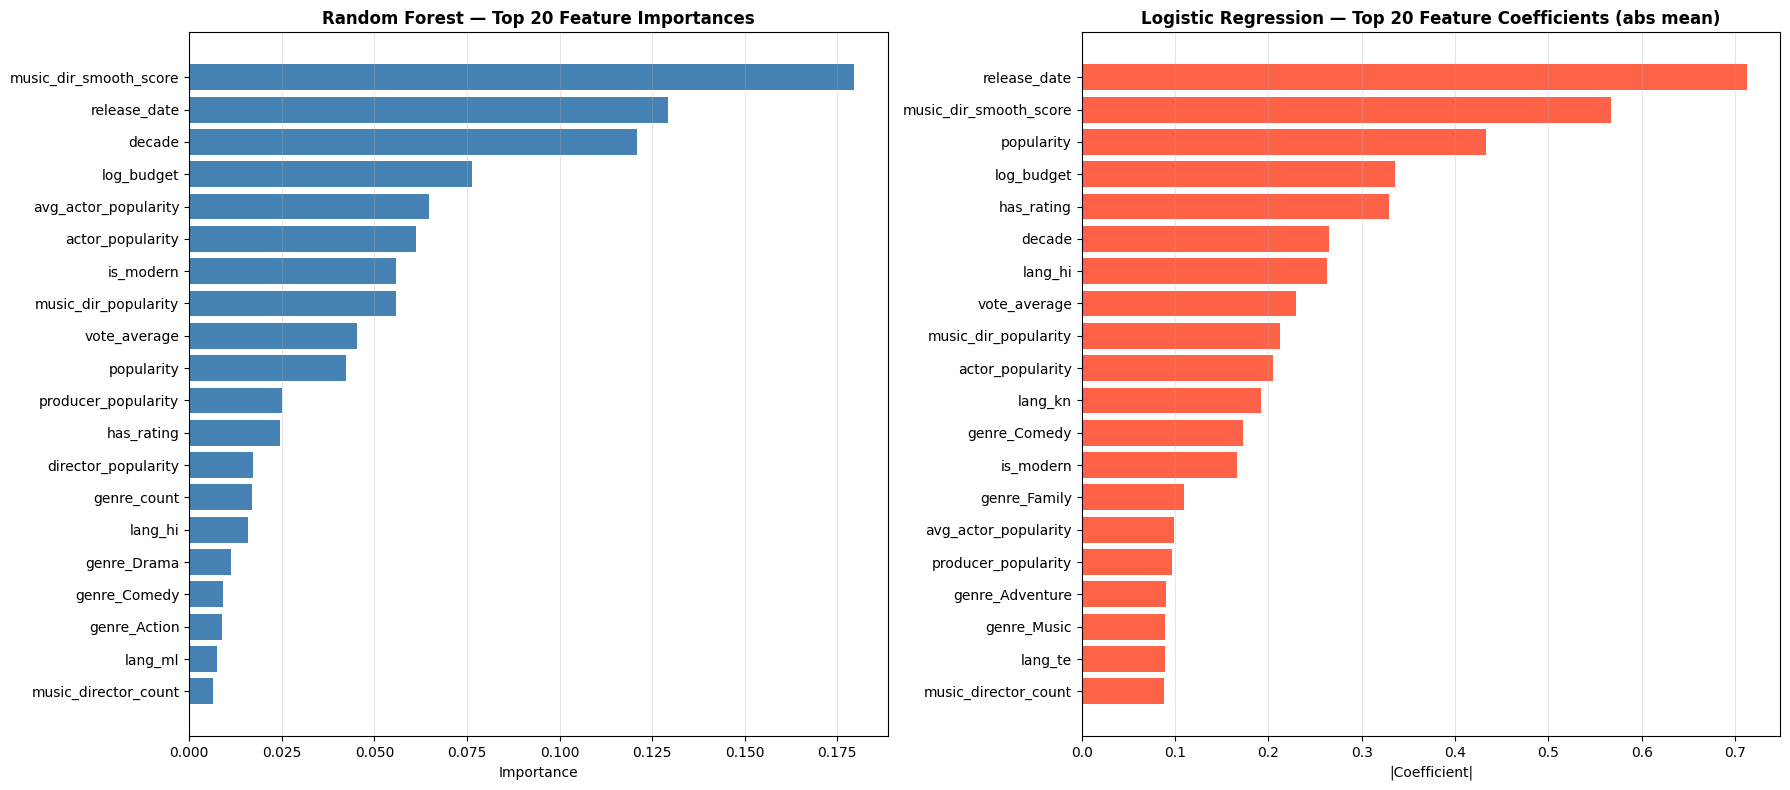

Saved: feature_importance.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Random Forest ──────────────────────────────────────────────────────
rf_pipe = trained_pipelines["Random Forest"]
rf_clf  = rf_pipe.named_steps['clf']
feat_names = X.columns.tolist()
importances = rf_clf.feature_importances_

top_n = 20
idx = np.argsort(importances)[-top_n:][::-1]
axes[0].barh([feat_names[j] for j in idx][::-1], importances[idx][::-1], color='steelblue')
axes[0].set_title("Random Forest — Top 20 Feature Importances", fontweight='bold')
axes[0].set_xlabel("Importance")
axes[0].grid(axis='x', alpha=0.3)

# ── Logistic Regression ────────────────────────────────────────────────
lr_pipe = trained_pipelines["Logistic Regression"]
lr_clf  = lr_pipe.named_steps['clf']
coefs   = np.abs(lr_clf.coef_).mean(axis=0)   # avg across classes

idx2 = np.argsort(coefs)[-top_n:][::-1]
axes[1].barh([feat_names[j] for j in idx2][::-1], coefs[idx2][::-1], color='tomato')
axes[1].set_title("Logistic Regression — Top 20 Feature Coefficients (abs mean)", fontweight='bold')
axes[1].set_xlabel("|Coefficient|")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")


## STEP 17 — Best Model Selection & Final Summary

In [19]:
# Select best model by Val F1 (primary) with tie-break on Overfit Gap
best_row = results_df.loc[results_df['Val F1'].idxmax()]
best_name = best_row['Model']
best_pipe = trained_pipelines[best_name]

print("=" * 60)
print(f"  🏆 BEST MODEL: {best_name}")
print("=" * 60)
print(f"  Val  F1     : {best_row['Val F1']:.4f}")
print(f"  Test F1     : {best_row['Test F1']:.4f}")
print(f"  Val  AUC    : {best_row['Val AUC']:.4f}")
print(f"  Test AUC    : {best_row['Test AUC']:.4f}")
print(f"  CV F1 Mean  : {best_row['CV F1 Mean']:.4f} ± {best_row['CV F1 Std']:.4f}")
print(f"  Overfit Gap : {best_row['Overfit Gap']:.4f}  (Train-Val accuracy difference)")
print("=" * 60)

print("\n📋 Final Ranked Table:")
print(results_df[["Model","Val F1","Test F1","Val AUC","Test AUC","CV F1 Mean","Overfit Gap"]]
      .sort_values("Val F1", ascending=False).to_string(index=False))


  🏆 BEST MODEL: Gradient Boosting
  Val  F1     : 0.7396
  Test F1     : 0.7557
  Val  AUC    : 0.8677
  Test AUC    : 0.8736
  CV F1 Mean  : 0.7365 ± 0.0220
  Overfit Gap : 0.1302  (Train-Val accuracy difference)

📋 Final Ranked Table:
              Model  Val F1  Test F1  Val AUC  Test AUC  CV F1 Mean  Overfit Gap
  Gradient Boosting  0.7396   0.7557   0.8677    0.8736      0.7365       0.1302
Logistic Regression  0.7290   0.6969   0.8406    0.8457      0.6997      -0.0146
      Random Forest  0.7238   0.7435   0.8548    0.8612      0.7177       0.1058
                SVM  0.7037   0.7109   0.8294    0.8480      0.6891       0.1387
      Decision Tree  0.6750   0.6594   0.8230    0.7965      0.6721       0.0440
                KNN  0.6213   0.6600   0.7752    0.8197      0.6008       0.4171


## STEP 18 — Music Director Impact Analysis

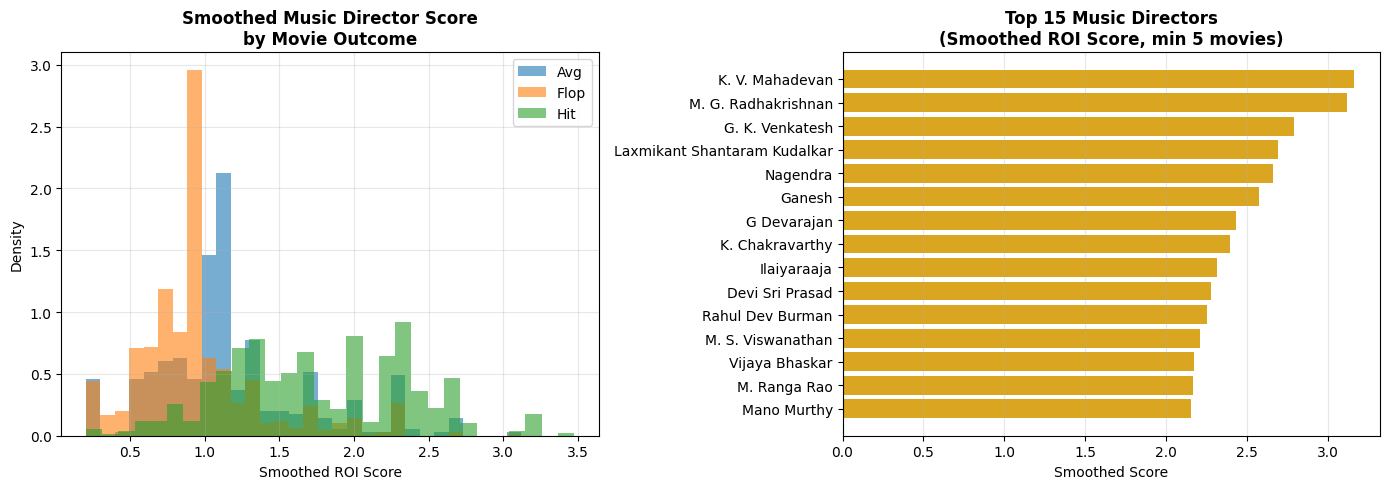

Saved: music_director_analysis.png


In [20]:
# Show how much the music director feature contributes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of music_dir_smooth_score by class
for lbl, grp in df.groupby('success_label'):
    axes[0].hist(grp['music_dir_smooth_score'], bins=30, alpha=0.6, label=lbl, density=True)
axes[0].set_title("Smoothed Music Director Score\nby Movie Outcome", fontweight='bold')
axes[0].set_xlabel("Smoothed ROI Score")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Top 15 music directors by smooth score (min 5 movies)
md_stats = df.groupby('primary_music_dir').agg(
    n=('roi','count'), smooth_score=('music_dir_smooth_score','first')
).reset_index()
md_stats = md_stats[md_stats['n'] >= 5].sort_values('smooth_score', ascending=False).head(15)

axes[1].barh(md_stats['primary_music_dir'][::-1], md_stats['smooth_score'][::-1], color='goldenrod')
axes[1].set_title("Top 15 Music Directors\n(Smoothed ROI Score, min 5 movies)", fontweight='bold')
axes[1].set_xlabel("Smoothed Score")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("music_director_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: music_director_analysis.png")
